# Bibliotecas

In [59]:
from IPython.display import display
from imblearn.over_sampling import SMOTE
import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.ensemble import (
    AdaBoostClassifier,
    GradientBoostingClassifier,
    RandomForestClassifier,
)
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
import warnings
from sklearn.metrics import RocCurveDisplay
import joblib

warnings.filterwarnings('ignore')

# Carregamento de dados

In [17]:
df = pd.read_excel(r'../data/base.xlsx')

# Interpretação dos dados

| Coluna | Variável Original | Descrição | Categorias |
| :--- | :--- | :--- | :--- |
| `ANO` | `ANO` | Anos de referência da pesquisa | 2024 e 2025 |
| `ID_DOMICILIO` | `ID_DOMICILIO` | Identificador único do domicílio | — |
| `ID_PESSOA` | `ID_PESSOA` | Identificador único da pessoa entrevistada | — |
| `IDADE` | `V2009` | Idade do morador na data de referência | Numérico |
| `SEXO` | `V2007` | Sexo | 1: Homem, 2: Mulher |
| `COR_OU_RACA` | `V2010` | Cor ou raça | 1: Branca, 2: Preta, 3: Amarela, 4: Parda, 5: Indígena, 9: Ignorado |
| `SITUACAO_DOMICILIO` | `V1022` | Situação do domicílio | 1: Urbana, 2: Rural |
| `ESTA_EM_REGIAO_METROPOLITANA` | `rm_ride` | ID Região Metropolitana | — |
| `NUMERO_PESSOAS_DOMICILIO` | `V2001` | Número total de pessoas residentes no domicílio | Numérico |
| `TIPO_PESSOA_NO_DOMICILIO` | `V2005` | Condição na família | 1: Responsável, 2-3: Cônjuge/companheiro(a), 4-5: Filho(a), 6: Enteado(a), 7: Genro/nora, 8: Pai/mãe/padrasto/madrasta, 9: Sogro(a), 10: Neto(a), 11: Bisneto(a), 12: Irmão/irmã, 13: Avô/avó, 14: Outro parente, 15-16: Não parente, 17: Pensionista, 18-19: Empregado(a) doméstico(a) ou parente |
| `FAIXA_RENDIMENTO_BRUTO` | `V403411` | Faixa de rendimento bruto | 0: 0, 1: até 0,5 SM, 2: >0,5 a 1 SM, 3: >1 a 2 SM, 4: >2 a 3 SM, 5: >3 a 5 SM, 6: >5 a 10 SM, 7: >10 a 20 SM, 8: >20 SM ou mais |
| `QUAL_SERIE_FREQUENTA` | `V3006` | Ano/série escolar que frequenta | Filtrado para o 2º ano |
| `TIPO_ESCOLA` | `V3002A` | Dependência administrativa da escola | 1: Rede privada, 2: Rede pública |
| `SABE_LER_E_ESCREVER` | `V3001` | Sabe ler e escrever | 1: Sim, 2: Não |

# Avaliação da base

In [18]:
df.describe()

,ANO,ID_PESSOA,IDADE,SEXO,COR_OU_RACA,ID_DOMICILIO,SITUACAO_DOMICILIO,ESTA_EM_REGIAO_METROPOLITANA,NUMERO_PESSOAS_DOMICILIO,TIPO_PESSOA_NO_DOMICILIO,FAIXA_RENDIMENTO_BRUTO,QUAL_SERIE_FREQUENTA,TIPO_ESCOLA,SABE_LER_E_ESCREVER
count,39766.000000,3.976600e+04,39766.0,39766.000000,39766.000000,3.976600e+04,39766.000000,11816.000000,39766.000000,39766.000000,39766.000000,39766.000000,39766.000000,39766.000000
mean,2024.520218,3.068137e+14,7.0,1.488457,2.716391,3.068137e+12,1.273425,30.613152,4.258688,5.286300,3.421239,1.648217,1.818639,1.277373
std,0.499597,1.141057e+14,0.0,0.499873,1.443234,1.141057e+12,0.445723,9.811739,1.384525,2.362526,1.615597,0.477533,0.385322,0.447708
min,2024.000000,1.100000e+14,7.0,1.000000,1.000000,1.100000e+12,1.000000,13.000000,2.000000,4.000000,0.000000,1.000000,1.000000,1.000000
25%,2024.000000,2.200580e+14,7.0,1.000000,1.000000,2.200580e+12,1.000000,24.000000,3.000000,4.000000,2.000000,1.000000,2.000000,1.000000
50%,2025.000000,3.101384e+14,7.0,1.000000,4.000000,3.101384e+12,1.000000,31.000000,4.000000,4.000000,3.000000,2.000000,2.000000,1.000000
75%,2025.000000,4.101228e+14,7.0,2.000000,4.000000,4.101228e+12,2.000000,35.000000,5.000000,5.000000,4.000000,2.000000,2.000000,2.000000
max,2025.000000,5.301137e+14,7.0,2.000000,9.000000,5.301137e+12,2.000000,52.000000,18.000000,19.000000,8.000000,2.000000,2.000000,2.000000


In [19]:
df.isna().sum()

ANO                                 0
ID_PESSOA                           0
IDADE                               0
SEXO                                0
COR_OU_RACA                         0
ID_DOMICILIO                        0
SITUACAO_DOMICILIO                  0
ESTA_EM_REGIAO_METROPOLITANA    27950
NUMERO_PESSOAS_DOMICILIO            0
TIPO_PESSOA_NO_DOMICILIO            0
FAIXA_RENDIMENTO_BRUTO              0
QUAL_SERIE_FREQUENTA                0
TIPO_ESCOLA                         0
SABE_LER_E_ESCREVER                 0
dtype: int64

# Tratamento de valores faltantes

In [20]:
df['ESTA_EM_REGIAO_METROPOLITANA'] = df['ESTA_EM_REGIAO_METROPOLITANA'].notna().astype(int)

In [21]:
df.isna().sum()

ANO                             0
ID_PESSOA                       0
IDADE                           0
SEXO                            0
COR_OU_RACA                     0
ID_DOMICILIO                    0
SITUACAO_DOMICILIO              0
ESTA_EM_REGIAO_METROPOLITANA    0
NUMERO_PESSOAS_DOMICILIO        0
TIPO_PESSOA_NO_DOMICILIO        0
FAIXA_RENDIMENTO_BRUTO          0
QUAL_SERIE_FREQUENTA            0
TIPO_ESCOLA                     0
SABE_LER_E_ESCREVER             0
dtype: int64

# Visualização gráfica dos dados

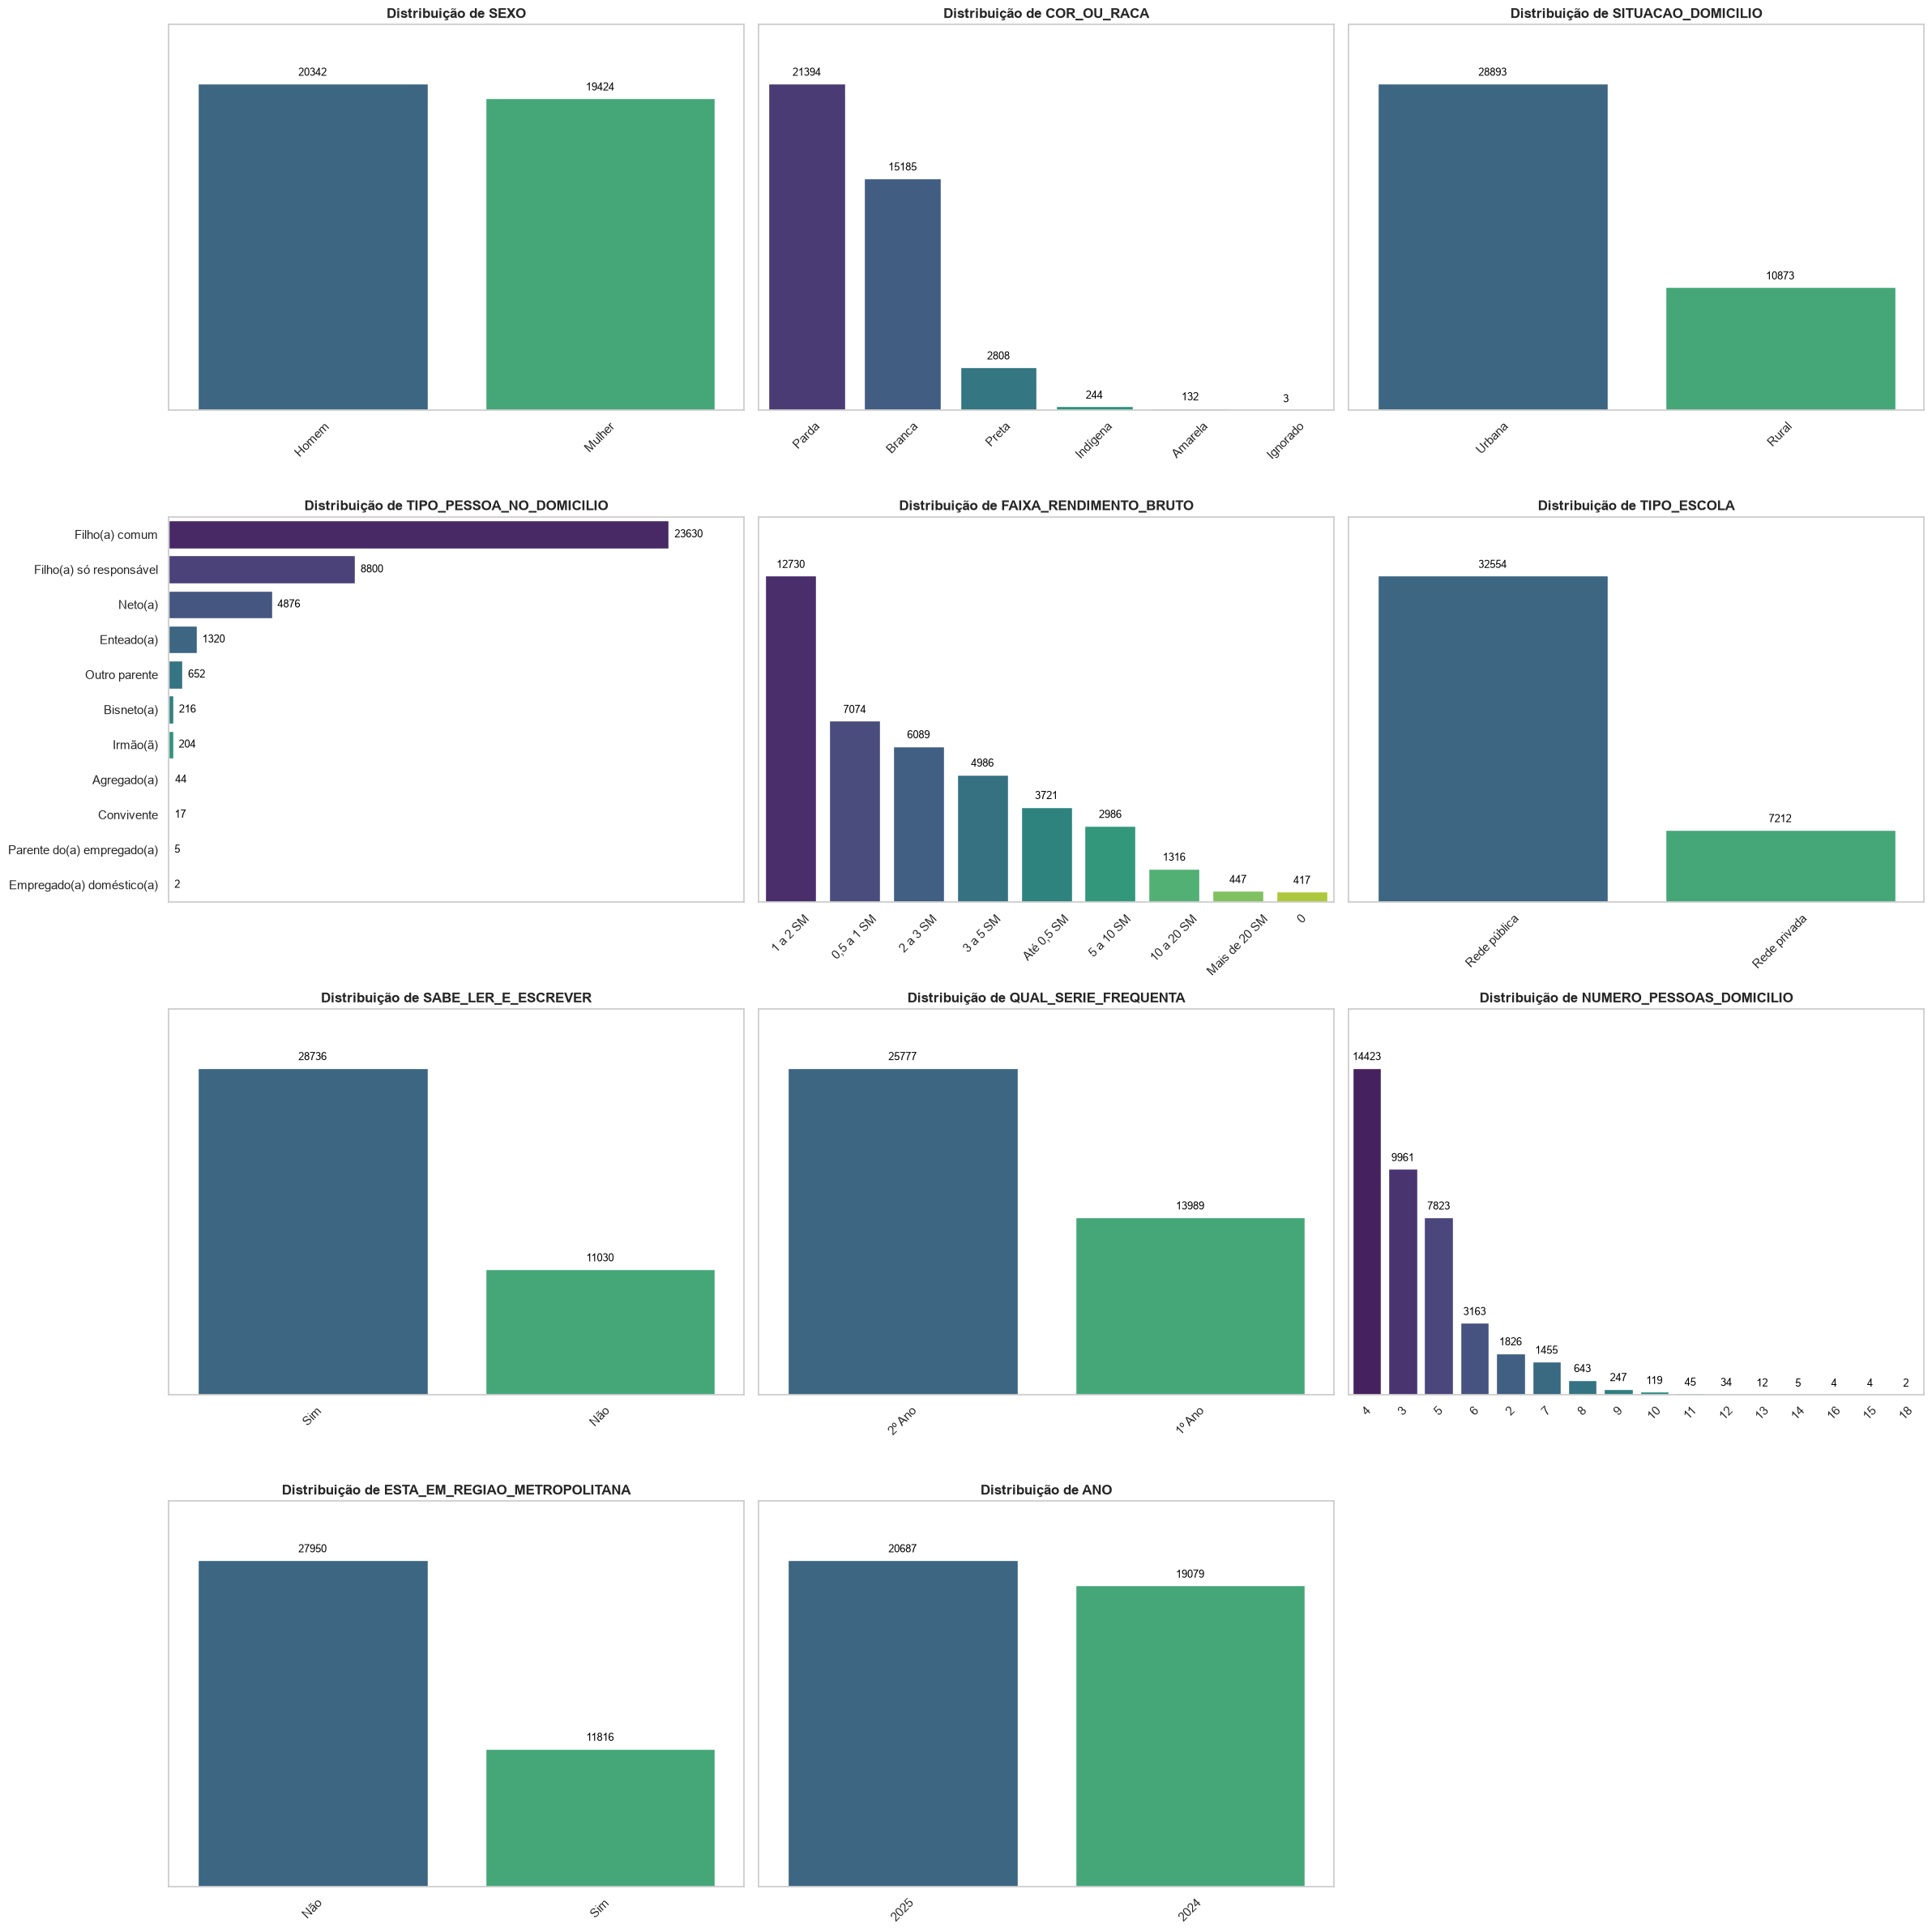

In [23]:
mapeamentos = {
    "SEXO": {1: "Homem", 2: "Mulher"},
    "ESTA_EM_REGIAO_METROPOLITANA": {0: "Não", 1: "Sim"},
    "COR_OU_RACA": {
        1: "Branca",
        2: "Preta",
        3: "Amarela",
        4: "Parda",
        5: "Indígena",
        9: "Ignorado",
    },
    "SITUACAO_DOMICILIO": {1: "Urbana", 2: "Rural"},
    "TIPO_PESSOA_NO_DOMICILIO": {
        1: "Responsável",
        2: "Cônjuge (diferente)",
        3: "Cônjuge (mesmo sexo)",
        4: "Filho(a) comum",
        5: "Filho(a) só responsável",
        6: "Enteado(a)",
        7: "Genro/nora",
        8: "Pai/mãe/padrasto/madrasta",
        9: "Sogro(a)",
        10: "Neto(a)",
        11: "Bisneto(a)",
        12: "Irmão(ã)",
        13: "Avô/avó",
        14: "Outro parente",
        15: "Agregado(a)",
        16: "Convivente",
        17: "Pensionista",
        18: "Empregado(a) doméstico(a)",
        19: "Parente do(a) empregado(a)",
    },
    "FAIXA_RENDIMENTO_BRUTO": {
        0: "0",
        1: "Até 0,5 SM",
        2: "0,5 a 1 SM",
        3: "1 a 2 SM",
        4: "2 a 3 SM",
        5: "3 a 5 SM",
        6: "5 a 10 SM",
        7: "10 a 20 SM",
        8: "Mais de 20 SM",
    },
    "TIPO_ESCOLA": {1: "Rede privada", 2: "Rede pública"},
    "SABE_LER_E_ESCREVER": {1: "Sim", 2: "Não"},
    "QUAL_SERIE_FREQUENTA": {"1": "1º Ano", "2": "2º Ano", 1: "1º Ano", 2: "2º Ano"}
}

df_plot = df.copy()
for col, mapa in mapeamentos.items():
    if col in df_plot.columns:
        df_plot[col] = df_plot[col].map(mapa).fillna(df_plot[col])

sns.set_theme(style="whitegrid")
colunas_socioeconomicas = [
    "SEXO",
    "COR_OU_RACA",
    "SITUACAO_DOMICILIO",
    "TIPO_PESSOA_NO_DOMICILIO",
    "FAIXA_RENDIMENTO_BRUTO",
    "TIPO_ESCOLA",
    "SABE_LER_E_ESCREVER",
    "QUAL_SERIE_FREQUENTA",
    "NUMERO_PESSOAS_DOMICILIO","ESTA_EM_REGIAO_METROPOLITANA",
    "ANO"
]

fig, axes = plt.subplots(4, 3, figsize=(24, 24))
axes = axes.flatten()

for i, coluna in enumerate(colunas_socioeconomicas):
    if coluna in df_plot.columns:
        ax = axes[i]
        if coluna == "TIPO_PESSOA_NO_DOMICILIO":
            sns.countplot(
                data=df_plot,
                y=coluna,
                ax=ax,
                palette="viridis",
                order=df_plot[coluna].value_counts().index
            )
            ax.set_title(f"Distribuição de {coluna}", fontsize=12, fontweight="bold")
            ax.set_ylabel("")
            ax.set_xlabel("")
            ax.set_xticks([])
            ax.grid(False, axis="x")
            
            max_width = df_plot[coluna].value_counts().max()
            ax.set_xlim(0, max_width * 1.15)
            
            for p in ax.patches:
                width = p.get_width()
                if width > 0:
                    ax.annotate(
                        f"{int(width)}",
                        (width, p.get_y() + p.get_height() / 2.0),
                        ha="left",
                        va="center",
                        fontsize=9,
                        color="black",
                        xytext=(5, 0),
                        textcoords="offset points",
                    )
        else:
            sns.countplot(
                data=df_plot,
                x=coluna,
                ax=ax,
                palette="viridis",
                order=df_plot[coluna].value_counts().index
            )
            ax.set_title(f"Distribuição de {coluna}", fontsize=12, fontweight="bold")
            ax.set_xlabel("")
            ax.set_ylabel("")
            ax.set_yticks([])
            ax.grid(False, axis="x")
            
            max_height = df_plot[coluna].value_counts().max()
            ax.set_ylim(0, max_height * 1.18)
            
            for p in ax.patches:
                height = p.get_height()
                if height > 0:
                    ax.annotate(
                        f"{int(height)}",
                        (p.get_x() + p.get_width() / 2.0, height),
                        ha="center",
                        va="bottom",
                        fontsize=9,
                        color="black",
                        xytext=(0, 5),
                        textcoords="offset points",
                    )
            
            ax.tick_params(axis="x", rotation=45)
    else:
        axes[i].set_visible(False)

for j in range(len(colunas_socioeconomicas), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

# Feature engineering

In [52]:
import pandas as pd
import numpy as np

df_feat = df.copy()

mapeamento_renda_mediana = {
    0: 0.0,
    1: 0.25,
    2: 0.75,
    3: 1.5,
    4: 2.5,
    5: 4.0,
    6: 7.5,
    7: 15.0,
    8: 25.0
}

df_feat['RENDA_NUMERICA_APROX'] = df_feat['FAIXA_RENDIMENTO_BRUTO'].map(mapeamento_renda_mediana)
df_feat['NUMERO_PESSOAS_DOMICILIO'] = pd.to_numeric(df_feat['NUMERO_PESSOAS_DOMICILIO'], errors='coerce')
df_feat['PROXY_RENDA_PER_CAPITA'] = df_feat['RENDA_NUMERICA_APROX'] / df_feat['NUMERO_PESSOAS_DOMICILIO']

df_feat['FLAG_BAIXA_RENDA'] = (df_feat['PROXY_RENDA_PER_CAPITA'] < 0.5).astype(int)
df_feat['FLAG_DISTORCAO_IDADE_SERIE'] = df_feat['QUAL_SERIE_FREQUENTA'].astype(str).apply(lambda x: 1 if '1' in x else 0)
df_feat['ESTA_EM_REGIAO_METROPOLITANA'] = df_feat['ESTA_EM_REGIAO_METROPOLITANA'].notna().astype(int)

df_feat['INDICE_VULNERABILIDADE'] = (
    (df_feat['SITUACAO_DOMICILIO'] == 2).astype(int) +
    df_feat['FLAG_BAIXA_RENDA'] +
    (df_feat['TIPO_ESCOLA'] == 2).astype(int) +
    df_feat['FLAG_DISTORCAO_IDADE_SERIE']
)

df_feat['ESCOLA_X_RENDA'] = df_feat['TIPO_ESCOLA'].astype(str) + "_" + pd.qcut(df_feat['PROXY_RENDA_PER_CAPITA'], q=4, labels=['Q1', 'Q2', 'Q3', 'Q4'], duplicates='drop').astype(str)
df_feat['ESCOLA_X_VULNERABILIDADE'] = df_feat['TIPO_ESCOLA'].astype(str) + "_" + df_feat['INDICE_VULNERABILIDADE'].astype(str)
df_feat['METROPOLITANA_X_RENDA'] = df_feat['ESTA_EM_REGIAO_METROPOLITANA'].astype(str) + "_" + df_feat['FAIXA_RENDIMENTO_BRUTO'].astype(str)

# Feature selection

In [61]:
features_analise = [
    "SEXO",
    "COR_OU_RACA",
    "SITUACAO_DOMICILIO",
    "TIPO_PESSOA_NO_DOMICILIO",
    "FAIXA_RENDIMENTO_BRUTO",
    "TIPO_ESCOLA",
    "QUAL_SERIE_FREQUENTA",
    "NUMERO_PESSOAS_DOMICILIO",
    "PROXY_RENDA_PER_CAPITA",
    "FLAG_DISTORCAO_IDADE_SERIE",
    "ESCOLA_X_RENDA",
    "INDICE_VULNERABILIDADE", 
    "METROPOLITANA_X_RENDA"
]

X_sel = df_feat[features_analise].copy()
for col in X_sel.columns:
    X_sel[col] = X_sel[col].astype("category").cat.codes

y_sel = pd.to_numeric(df_feat["SABE_LER_E_ESCREVER"], errors='coerce')
y_sel = y_sel.apply(lambda val: 1 if val == 1 else (0 if val == 2 else val))

chi2_selector = SelectKBest(score_func=chi2, k="all")
chi2_selector.fit(X_sel, y_sel)

df_chi2 = pd.DataFrame({
    "Variável": features_analise,
    "Chi2_Score": chi2_selector.scores_,
    "P_Value": chi2_selector.pvalues_
}).sort_values(by="Chi2_Score", ascending=False)

X_tr_s, X_te_s, y_tr_s, y_te_s = train_test_split(X_sel, y_sel, test_size=0.2, random_state=42, stratify=y_sel)
model_temp = lgb.LGBMClassifier(random_state=42, verbose=-1)
model_temp.fit(X_tr_s, y_tr_s)

df_lgb_importance = pd.DataFrame({
    "Variável": features_analise,
    "Importancia_Gain": model_temp.booster_.feature_importance(importance_type='gain')
}).sort_values(by="Importancia_Gain", ascending=False)

perm_importance = permutation_importance(
    model_temp, X_te_s, y_te_s, n_repeats=10, random_state=42, scoring='roc_auc'
)

df_perm = pd.DataFrame({
    "Variável": features_analise,
    "Permutation_Importance_Mean": perm_importance.importances_mean
}).sort_values(by="Permutation_Importance_Mean", ascending=False)

display(df_chi2)
display(df_lgb_importance)
display(df_perm)

,Variável,Chi2_Score,P_Value
8,PROXY_RENDA_PER_CAPITA,11763.685887,0.000000e+00
12,METROPOLITANA_X_RENDA,1601.892918,0.000000e+00
4,FAIXA_RENDIMENTO_BRUTO,1601.892918,0.000000e+00
11,INDICE_VULNERABILIDADE,1495.412885,0.000000e+00
1,COR_OU_RACA,601.620870,7.434431e-133
2,SITUACAO_DOMICILIO,481.260888,1.135999e-106
9,FLAG_DISTORCAO_IDADE_SERIE,368.028158,5.029541e-82
7,NUMERO_PESSOAS_DOMICILIO,351.411737,2.087928e-78
6,QUAL_SERIE_FREQUENTA,199.726341,2.396352e-45
5,TIPO_ESCOLA,174.287882,8.564788e-40


,Variável,Importancia_Gain
11,INDICE_VULNERABILIDADE,10415.521895
8,PROXY_RENDA_PER_CAPITA,4174.329003
4,FAIXA_RENDIMENTO_BRUTO,1528.411267
7,NUMERO_PESSOAS_DOMICILIO,1422.586569
1,COR_OU_RACA,1234.577557
3,TIPO_PESSOA_NO_DOMICILIO,1143.641375
6,QUAL_SERIE_FREQUENTA,845.938341
0,SEXO,720.652852
2,SITUACAO_DOMICILIO,320.928754
10,ESCOLA_X_RENDA,187.288065


,Variável,Permutation_Importance_Mean
11,INDICE_VULNERABILIDADE,0.067955
8,PROXY_RENDA_PER_CAPITA,0.035838
6,QUAL_SERIE_FREQUENTA,0.010978
1,COR_OU_RACA,0.010696
4,FAIXA_RENDIMENTO_BRUTO,0.009225
3,TIPO_PESSOA_NO_DOMICILIO,0.006589
0,SEXO,0.006483
7,NUMERO_PESSOAS_DOMICILIO,0.004131
5,TIPO_ESCOLA,0.001912
10,ESCOLA_X_RENDA,0.001387


# Treinamento

In [62]:
features_finais_categoricas = [
    'SEXO',
    'COR_OU_RACA',
    'SITUACAO_DOMICILIO',
    'TIPO_PESSOA_NO_DOMICILIO',
    'FAIXA_RENDIMENTO_BRUTO',
    'TIPO_ESCOLA',
    'QUAL_SERIE_FREQUENTA',
    'ESCOLA_X_VULNERABILIDADE'
]

features_finais_numericas = [
    'NUMERO_PESSOAS_DOMICILIO',
    'PROXY_RENDA_PER_CAPITA',
    'FLAG_DISTORCAO_IDADE_SERIE',
    'INDICE_VULNERABILIDADE'
]

X_cat = pd.get_dummies(df_feat[features_finais_categoricas].astype(str), drop_first=True)
X_num = df_feat[features_finais_numericas].apply(pd.to_numeric, errors='coerce').fillna(0)

X = pd.concat([X_num, X_cat], axis=1)
y = pd.to_numeric(df_feat['SABE_LER_E_ESCREVER'], errors='coerce')
y = y.apply(lambda val: 1 if val == 1 else (0 if val == 2 else val))

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

smote = SMOTE(sampling_strategy='auto', random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

modelos = {
    'Random Forest (SMOTE)': RandomForestClassifier(
        n_estimators=500, max_depth=15, min_samples_split=5, random_state=42, n_jobs=-1
    ),
    'LightGBM (Balanced)': lgb.LGBMClassifier(
        n_estimators=300, learning_rate=0.03, num_leaves=63, class_weight='balanced', random_state=42, verbose=-1
    ),
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=300, max_depth=6, learning_rate=0.03, random_state=42
    ),
    'Decision Tree (SMOTE)': DecisionTreeClassifier(
        max_depth=15, random_state=42
    ),
}

modelos_treinados = {}
for nome, modelo in modelos.items():
    if 'SMOTE' in nome or 'Decision Tree' in nome:
        modelo.fit(X_train_smote, y_train_smote)
    else:
        modelo.fit(X_train, y_train)
    modelos_treinados[nome] = modelo

for nome, modelo in modelos_treinados.items():
    preds_proba = modelo.predict_proba(X_test)[:, 1]
    print(f'Modelo: {nome} | ROC-AUC: {roc_auc_score(y_test, preds_proba):.4f}')

Modelo: Random Forest (SMOTE) | ROC-AUC: 0.6841
Modelo: LightGBM (Balanced) | ROC-AUC: 0.6892
Modelo: Gradient Boosting | ROC-AUC: 0.6929
Modelo: Decision Tree (SMOTE) | ROC-AUC: 0.6550


# Avaliação

=== Modelo: Random Forest (SMOTE) ===
Melhor Threshold (F1 Classe 0): 0.6650
ROC-AUC: 0.6841

              precision    recall  f1-score   support

           0       0.34      0.87      0.49      2206
           1       0.88      0.34      0.49      5748

    accuracy                           0.49      7954
   macro avg       0.61      0.61      0.49      7954
weighted avg       0.73      0.49      0.49      7954



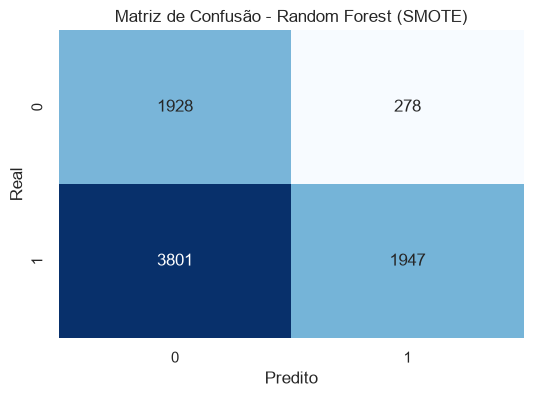



=== Modelo: LightGBM (Balanced) ===
Melhor Threshold (F1 Classe 0): 0.6404
ROC-AUC: 0.6892

              precision    recall  f1-score   support

           0       0.34      0.88      0.49      2206
           1       0.88      0.33      0.48      5748

    accuracy                           0.49      7954
   macro avg       0.61      0.61      0.49      7954
weighted avg       0.73      0.49      0.49      7954



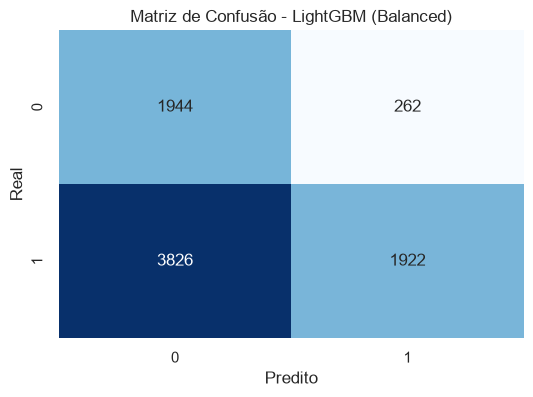



=== Modelo: Gradient Boosting ===
Melhor Threshold (F1 Classe 0): 0.8226
ROC-AUC: 0.6929

              precision    recall  f1-score   support

           0       0.33      0.89      0.48      2206
           1       0.88      0.31      0.46      5748

    accuracy                           0.47      7954
   macro avg       0.60      0.60      0.47      7954
weighted avg       0.73      0.47      0.47      7954



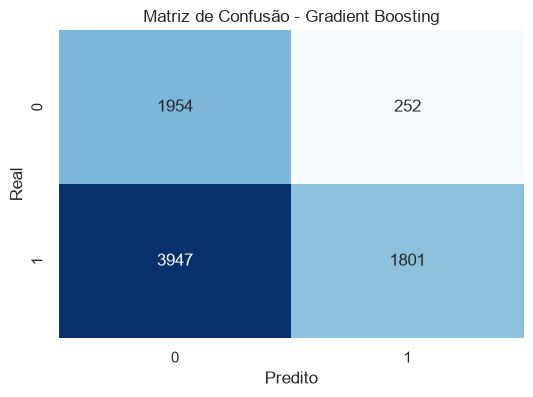



=== Modelo: Decision Tree (SMOTE) ===
Melhor Threshold (F1 Classe 0): 0.6847
ROC-AUC: 0.6550

              precision    recall  f1-score   support

           0       0.33      0.84      0.47      2206
           1       0.85      0.34      0.49      5748

    accuracy                           0.48      7954
   macro avg       0.59      0.59      0.48      7954
weighted avg       0.71      0.48      0.48      7954



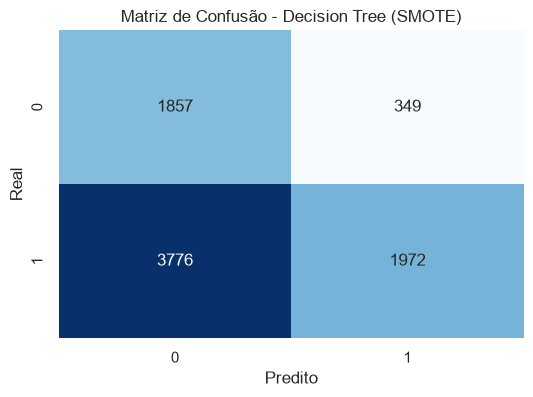

In [63]:
for nome, modelo in modelos_treinados.items():
    preds_proba = modelo.predict_proba(X_test)[:, 1]
    
    thresholds = np.linspace(0.01, 0.99, 200)
    best_thresh = 0.5
    best_score = 0
    
    for t in thresholds:
        preds_t = (preds_proba >= t).astype(int)
        # score = f1_score(y_test, preds_t, pos_label=0)
        from sklearn.metrics import fbeta_score
        score = fbeta_score(y_test, preds_t, beta=1.5, pos_label=0)
        if score > best_score:
            best_score = score
            best_thresh = t
            
    preds = (preds_proba >= best_thresh).astype(int)
    
    print(f"=== Modelo: {nome} ===")
    print(f"Melhor Threshold (F1 Classe 0): {best_thresh:.4f}")
    print(f"ROC-AUC: {roc_auc_score(y_test, preds_proba):.4f}\n")
    print(classification_report(y_test, preds))
    
    cm = confusion_matrix(y_test, preds)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.xlabel('Predito')
    plt.ylabel('Real')
    plt.title(f'Matriz de Confusão - {nome}')
    plt.show()
    print("\n" + "="*50 + "\n")

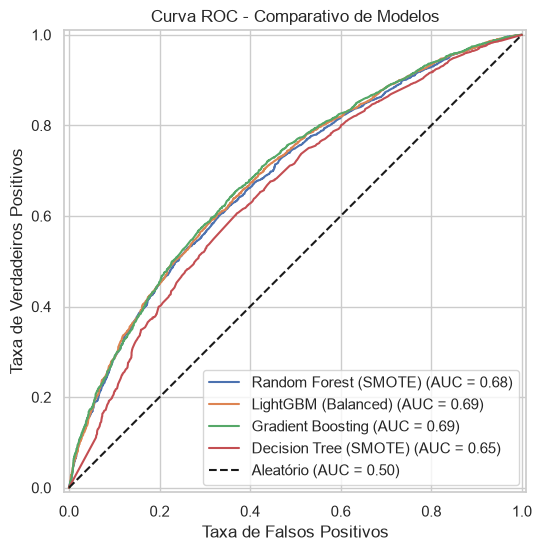

In [64]:
plt.figure(figsize=(8, 6))

for nome, modelo in modelos_treinados.items():
  preds_proba = modelo.predict_proba(X_test)[:, 1]
  RocCurveDisplay.from_estimator(
      modelo, X_test, y_test, name=nome, ax=plt.gca()
  )

plt.plot([0, 1], [0, 1], 'k--', label='Aleatório (AUC = 0.50)')
plt.xlabel('Taxa de Falsos Positivos')
plt.ylabel('Taxa de Verdadeiros Positivos')
plt.title('Curva ROC - Comparativo de Modelos')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

# Salvar melhor modelo

In [65]:
melhor_score = -1
melhor_modelo = None

for nome, modelo in modelos_treinados.items():
  preds_proba = modelo.predict_proba(X_test)[:, 1]
  score = roc_auc_score(y_test, preds_proba)
  if score > melhor_score:
    melhor_score = score
    melhor_modelo = modelo

joblib.dump(
    melhor_modelo,
    r'C:\Users\julia\Desktop\projects\tech-challenge-fase-3\notebooks\best.pkl',
)

['C:\\Users\\julia\\Desktop\\projects\\tech-challenge-fase-3\\notebooks\\best.pkl']